This is the main tutorial notebook. It is intended to introduce the basic machinery and how it is used.

First, let's import everything we need.

In [205]:
# import packages
%matplotlib inline
import numpy as np
import math
import sys
# sys.path.append('.')  # or full path to CompSep
np.math = math  # Redirect numpy.math to the built-in math module
import torch
import denoising
import importlib
denoising = importlib.reload(denoising)
import utils
utils = importlib.reload(utils)
import matplotlib.pyplot as plt

Here we import the data. Since this is simulation data of log column density (in units of $1/cm^3$). If the data is already preprocessed, you can just import it as is.

In [206]:
# Load the column density map from file
logN_H = np.load('Archive/Turb_3.npy')[1]  
# logN_H = utils.downsample_by_four(logN_H)
nx, ny = logN_H.shape

dx, dy = nx // 4, ny // 4
logN_H = logN_H[nx//2 - dx : nx//2 + dx, ny//2 - dy : ny//2 + dy]

# Define constant dust temperature
T_d = 10  # Typical Planck dust temperature in K

# int_val = []
# for nu in nu_list:
#     int_val.append(np.mean(modified_blackbody(logN_H, T_d, nu*1e9)))
# int_val = np.array(int_val)

# Observation frequency (e.g., 353 GHz in Hz)

# Compute the mock observed intensity map in μK_CMB
nu = (217,353)
# I_nu_map_μK_nu1 = utils.modified_blackbody(logN_H, T_d, nu[0]*1e9)
# I_nu_map_μK_nu2 = utils.modified_blackbody(logN_H, T_d, nu[1]*1e9)
alpha_1 = utils.MBB_factor(T_d, nu[0]*1e9)
alpha_2 = utils.MBB_factor(T_d, nu[1]*1e9)
I_nu_map_μK_nu1 = 10**logN_H*alpha_1
I_nu_map_μK_nu2 = 10**logN_H*alpha_2

I_nu_map_μK = (I_nu_map_μK_nu1, I_nu_map_μK_nu2)

The arrays that we work with need to have dimension `(1, H, W)`.

Now we define tuples of dust which will be our ground truth $s$, white noise, $n$, and finally cmb $c$. For simplicity the CMB here is modelled as a simple Gaussian random field with a falling power law for the power spectrum.

Keep in mind that in general, you can just import your own contamination array, respecting the broadcasting.

In [207]:
#Compute linear scale of images
M,N = I_nu_map_μK_nu1.shape
#Compute maximum diadic scale for computation
J = int(np.log2(M)) - 1

# Ensure inputs have shape (1, M, N)
dust_nu1 = I_nu_map_μK_nu1[None, :, :]
dust_nu2 = I_nu_map_μK_nu2[None, :, :]

dust = (dust_nu1, dust_nu2)

# --- CMB Parameters ---
n_realizations = 100
SNR = 2
nx, ny = dust_nu1.shape[-2], dust_nu1.shape[-1]

# --- Compute noise variances ---
variance_nu1 = (np.std(dust_nu1) / SNR) ** 2
variance_nu2 = (np.std(dust_nu2) / SNR) ** 2
variance = (variance_nu1, variance_nu2)

# --- Create contamination_arr with shape (n_realizations, 2, 1, H, W) ---
contamination_arr = np.zeros((n_realizations, 2, 1, nx, ny), dtype=np.float32)

for i in range(n_realizations):
    # Independent noise: shape (1, H, W)
    noise_nu1 = np.random.normal(0, np.sqrt(variance_nu1), (1, nx, ny)) 
    noise_nu2 = np.random.normal(0, np.sqrt(variance_nu2), (1, nx, ny))

    # Total contamination: shape (1, H, W)
    contamination_arr[i, 0] = noise_nu1 
    contamination_arr[i, 1] = noise_nu2

contamination_arr_nu1 = contamination_arr[:, 0]  # shape: (Mn, 1, H, W)
contamination_arr_nu2 = contamination_arr[:, 1]  # shape: (Mn, 1, H, W)

Here we create our data, given by the equation $d^\nu = s^\nu + c^\nu$ for each frequency band $\nu$. Notice that we are assuming that we can sample configures $c \sim P(c)$. Here, for simplicity, $c$ is white noise. While for this case this might be possible, in general for more complicated contaminations this may be more difficult. This is a strong assumption.

The tuple contains the data for two channels, that is, $(d^{\nu_1}, d^{\nu_2})$.

In [208]:
noise_nu1 = np.random.normal(0, np.sqrt(variance_nu1), dust_nu1.shape)
noise_nu2 = np.random.normal(0, np.sqrt(variance_nu2), dust_nu2.shape)

noise = (noise_nu1, noise_nu2)

data_nu1 = dust_nu1 + noise_nu1
data_nu2 = dust_nu2 + noise_nu2

# define target
data = (data_nu1, data_nu2)
data = tuple(img for img in data)

If $x$ is an image, then $\phi(x)$ denotes a set of summary statistics. For example, if can be the pixel average, and the pixel wide standard deviation. In that case, it would be $\phi(x) = ( \mu, \sigma )$. We are going to work with a different kind of coefficients, called Scattering Covariances

In [209]:
# definte initial maps for optimisation
image_init = data

In [210]:
image_init = data
threshold_func = None
remove_edge = False

std = {
    'single': denoising.compute_std(image_init, contamination_arr=contamination_arr,
                                    s_cov_func=threshold_func, remove_edge=remove_edge, precision='single')
}

In [211]:
n_epochs = 3 #number of epochs
# decontaminate
for i in range(n_epochs):
    print(f'Starting epoch {i+1}')
    running_map = denoising.denoise(data, contamination_arr = contamination_arr, std = std, seed=0, print_each_step=True, fixed_img= None,
                                    steps = 25, n_batch = 25, s_cov_func=threshold_func, image_init = image_init, remove_edge=remove_edge, precision='single', 
                                    if_large_batch=False, epochNo = i)
    running_map = (running_map[0], running_map[1])
    # image_init = running_map


    std = {
        'single': denoising.compute_std(running_map, contamination_arr=contamination_arr,
                                        s_cov_func=threshold_func, remove_edge=remove_edge, precision='single')
    }
    image_init = data


Starting epoch 1
Current Loss: 8.00e+00
Current Loss: 8.08e+00
Current Loss: 8.03e+00


KeyboardInterrupt: 

Remove modes above Nyquist frequency

In [200]:
lam = 0.55
result_nu1 = denoising.filter_radial(np.array([running_map[0]]), lambda k: k < nx * lam)[0]
result_nu2 = denoising.filter_radial(np.array([running_map[1]]), lambda k: k < nx * lam)[0]
result = (result_nu1, result_nu2)

Plot results

In [201]:
def plot(img1, img2, img3, titles=None, cmap='magma'):
    """
    Plots three images side by side.

    Parameters:
        img1, img2, img3: Images to display (NumPy arrays or similar).
        titles: Optional list of three titles for the subplots.
        cmap: Colormap to use (default is 'gray').
    """
    images = [img1, img2, img3]
    
    if titles is None:
        titles = ['True signal', 'Observed Data', 'Reconstruction']
    
    plt.figure(figsize=(12, 4))
    for i, img in enumerate(images):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img, cmap=cmap)
        plt.axis('off')
        plt.title(titles[i])
    plt.tight_layout()
    plt.show()

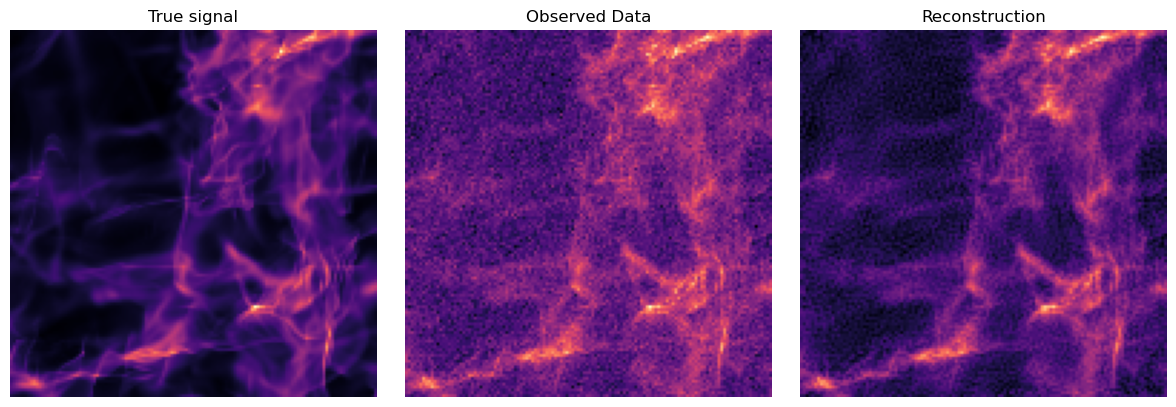

In [ ]:
plot(dust_nu2[0], data_nu2[0], result_nu2[0])

In [203]:
def plot_ps_components(freq_idx, data, dust, result, contamination_arr, k_max=None):
    """
    Plot power spectra components for a given frequency index (0 or 1), with optional k_max cutoff.

    Parameters:
    - freq_idx: int (0 or 1), selects which frequency to plot
    - data, dust, result: tuples/lists of 2 arrays each with shape (1, M, N)
    - contamination_arr: array of shape (n_contaminants, 2, 1, M, N)
    - k_max: float or None. If set, trims modes with k >= k_max
    """
    def trim(k, P):
        if k_max is None:
            return k, P
        mask = k < k_max
        return k[mask], P[mask]

    k_data, P_data = utils.power_spectrum(data[freq_idx][0])
    k_data, P_data = trim(k_data, P_data)
    plt.loglog(k_data, P_data, label=r"$d$", c="r")

    k_dust, P_dust = utils.power_spectrum(dust[freq_idx][0])
    k_dust, P_dust = trim(k_dust, P_dust)
    plt.loglog(k_dust, P_dust, label=r"$s$", c="b")

    k_noise, P_noise = utils.power_spectrum(contamination_arr[0][freq_idx][0])
    k_noise, P_noise = trim(k_noise, P_noise)
    plt.loglog(k_noise, P_noise, label=r"$n$", c="orange")

    k_result, P_result = utils.power_spectrum(result[freq_idx][0])
    k_result, P_result = trim(k_result, P_result)
    plt.loglog(k_result, P_result, label=r"$\hat{s}$", c="green")

    plt.legend()
    plt.xlabel(r"$k$")
    plt.ylabel(r"$P(k)$")
    plt.title(f"Power Spectra at freq_idx = {freq_idx}")
    plt.tight_layout()
    plt.show()

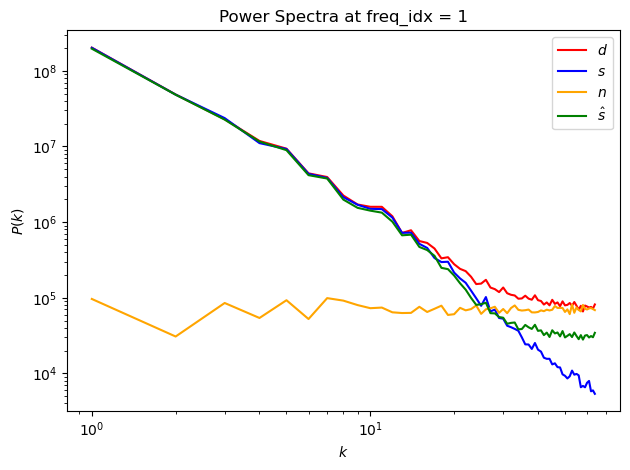

In [204]:
plot_ps_components(1, data, dust, result, contamination_arr)